In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, probplot, boxcox

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder , OrdinalEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
data = pd.read_csv('/cleaned_telco.csv')

In [ ]:


X = data.drop('Churn', axis=1)
y = data['Churn']

# Splitting data (80% Train, 20% Test) with stratify to prevent class imbalance issues
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()
robust_scaler = RobustScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create copies to avoid SettingWithCopyWarning
X_train_minmax, X_test_minmax = X_train.copy(), X_test.copy()
X_train_std, X_test_std = X_train.copy(), X_test.copy()
X_train_robust, X_test_robust = X_train.copy(), X_test.copy()

# 3. Fit on TRAIN ONLY, then Transform BOTH Train and Test (Prevent Data Leakage)
X_train_minmax[num_cols] = minmax_scaler.fit_transform(X_train[num_cols])
X_test_minmax[num_cols] = minmax_scaler.transform(X_test[num_cols])

X_train_std[num_cols] = std_scaler.fit_transform(X_train[num_cols])
X_test_std[num_cols] = std_scaler.transform(X_test[num_cols])

X_train_robust[num_cols] = robust_scaler.fit_transform(X_train[num_cols])
X_test_robust[num_cols] = robust_scaler.transform(X_test[num_cols])


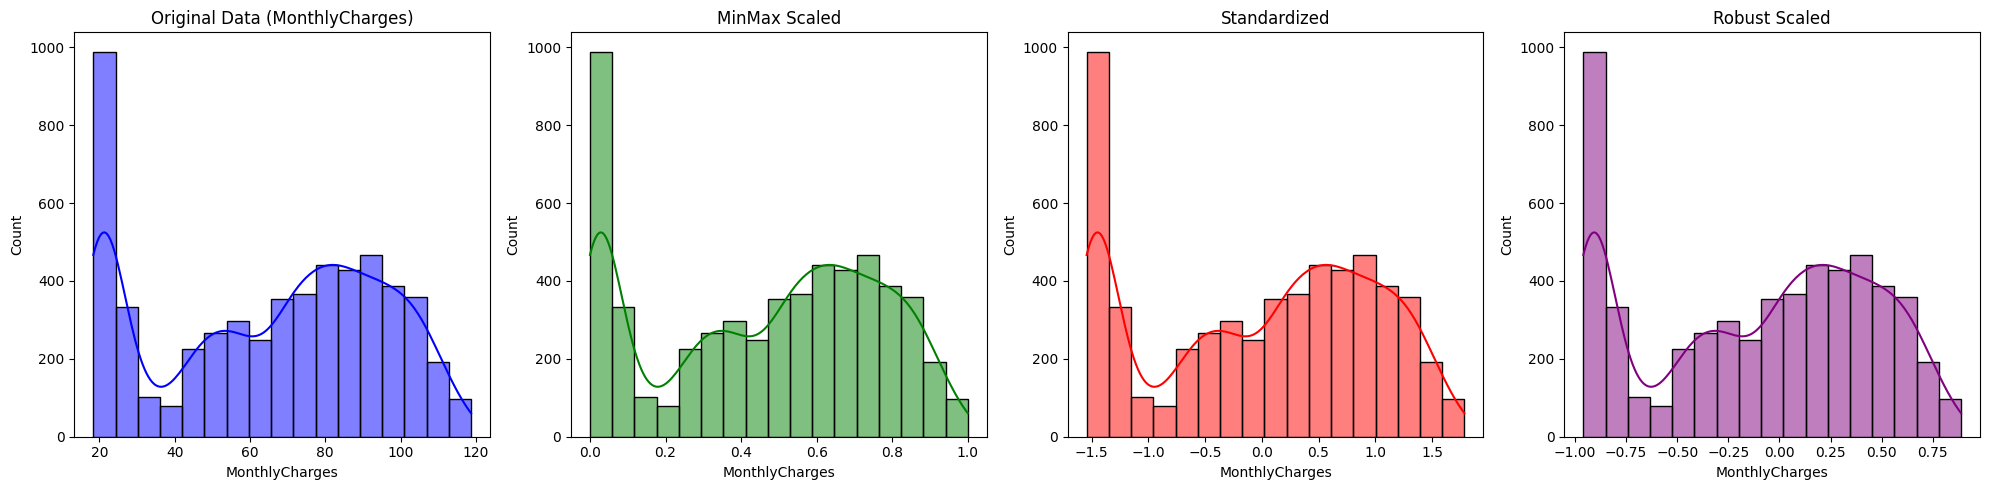

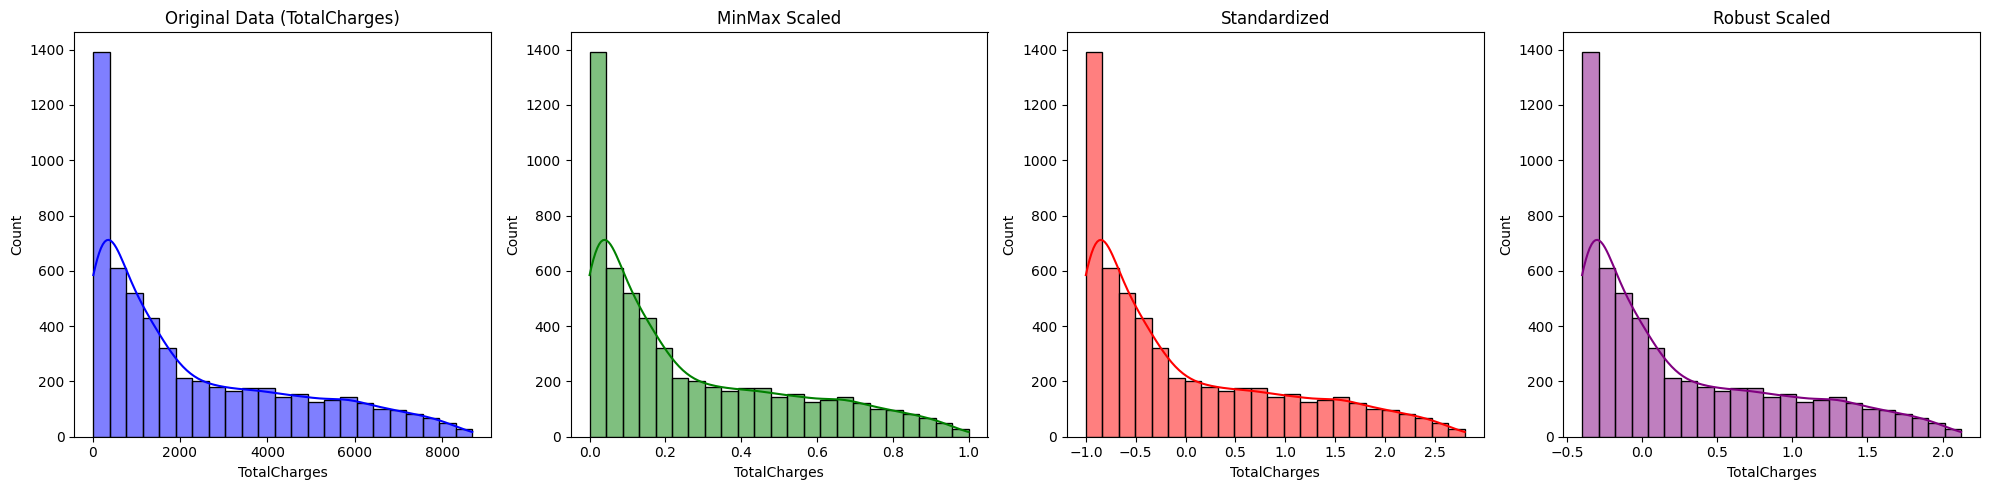

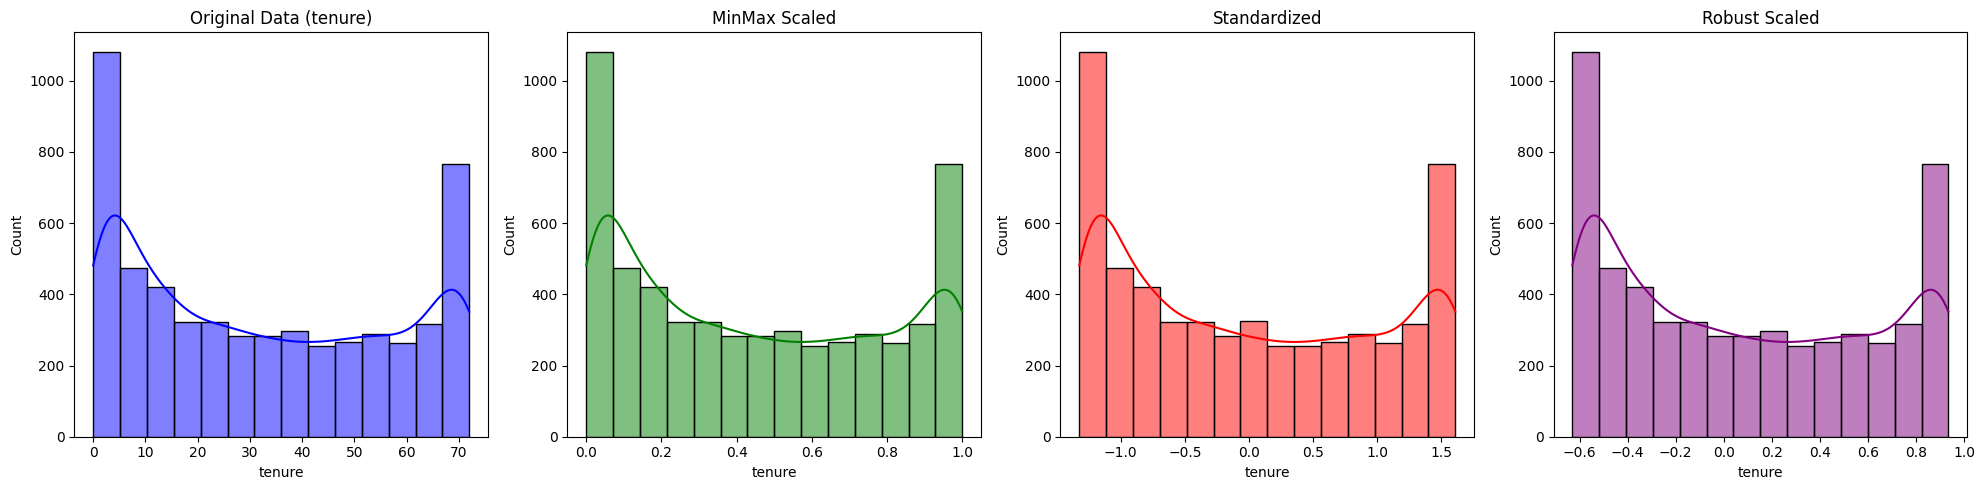

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['MonthlyCharges', 'TotalCharges', 'tenure']

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    sns.histplot(X_train[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f'Original Data ({col})')

    sns.histplot(X_train_minmax[col], kde=True, ax=axes[1], color='green')
    axes[1].set_title('MinMax Scaled')

    sns.histplot(X_train_std[col], kde=True, ax=axes[2], color='red')
    axes[2].set_title('Standardized')

    sns.histplot(X_train_robust[col], kde=True, ax=axes[3], color='purple')
    axes[3].set_title('Robust Scaled')

    plt.tight_layout()
    plt.show()

In [ ]:
# 4. Comparison Table for min/max/mean/std
def get_scaling_stats(df, name):
    stats = df[num_cols].agg(['min', 'max', 'mean', 'std']).T
    stats.columns = pd.MultiIndex.from_product([[name], stats.columns])
    return stats

stats_original = get_scaling_stats(X_train, 'Original Data')
stats_minmax = get_scaling_stats(X_train_minmax, 'MinMax Scaled')
stats_std = get_scaling_stats(X_train_std, 'Standardized')
stats_robust = get_scaling_stats(X_train_robust, 'Robust Scaled')

comparison_table = pd.concat([stats_original, stats_minmax, stats_std, stats_robust], axis=1)
print("Scaling Comparison Table:")
display(comparison_table.round(3))

Scaling Comparison Table:


Original Data                              MinMax Scaled       \
                         min      max      mean       std           min  max   
tenure                  0.00    72.00    32.485    24.569           0.0  1.0   
MonthlyCharges         18.40   118.75    64.930    30.138           0.0  1.0   
TotalCharges           18.85  8684.80  2299.394  2279.145           0.0  1.0   

                             Standardized                  Robust Scaled  \
                 mean    std          min    max mean  std           min   
tenure          0.451  0.341       -1.322  1.608 -0.0  1.0        -0.630   
MonthlyCharges  0.464  0.300       -1.544  1.786 -0.0  1.0        -0.959   
TotalCharges    0.263  0.263       -1.001  2.802 -0.0  1.0        -0.401   

                                     
                  max   mean    std  
tenure          0.935  0.076  0.534  
MonthlyCharges  0.888 -0.103  0.555  
TotalCharges    2.124  0.263  0.664

## **Which scaler is most appropriate for the Telco dataset and why?**

---

The MinMaxScaler is the optimal scaling technique for the numerical features in the Telco dataset (tenure, MonthlyCharges, TotalCharges).

Justification:

**Bounded Data & No Outliers:** The features have strict logical boundaries and lack extreme outliers. MinMaxScaler operates optimally under these conditions.

**Shape Preservation:** It scales all features uniformly into a strict [0, 1] range while perfectly preserving the exact shape of the original distributions. This prevents distance-based algorithms from being biased by the inherently larger magnitude of TotalCharges.

**Low Latency & Real-Time Inference (Production Constraint):** From a system engineering perspective, MinMaxScaler relies on O(1) basic arithmetic (subtraction and division). During real-time production inference, applying this transformation to incoming streaming data introduces virtually zero computational overhead, strictly satisfying low-latency performance requirements.

In [ ]:

cols_to_check = ['MonthlyCharges', 'TotalCharges']

print("--- 3.1 Identify Skewness (Before Transformation) ---")
for col in cols_to_check:
    skew_val = skew(X_train[col])
    classification = "Right-skewed" if skew_val > 0.5 else "Left-skewed" if skew_val < -0.5 else "Approximately Symmetric"
    print(f"{col} Skewness: {skew_val:.3f} -> {classification}")

--- 3.1 Identify Skewness (Before Transformation) ---
MonthlyCharges Skewness: -0.224 -> Approximately Symmetric
TotalCharges Skewness: 0.949 -> Right-skewed


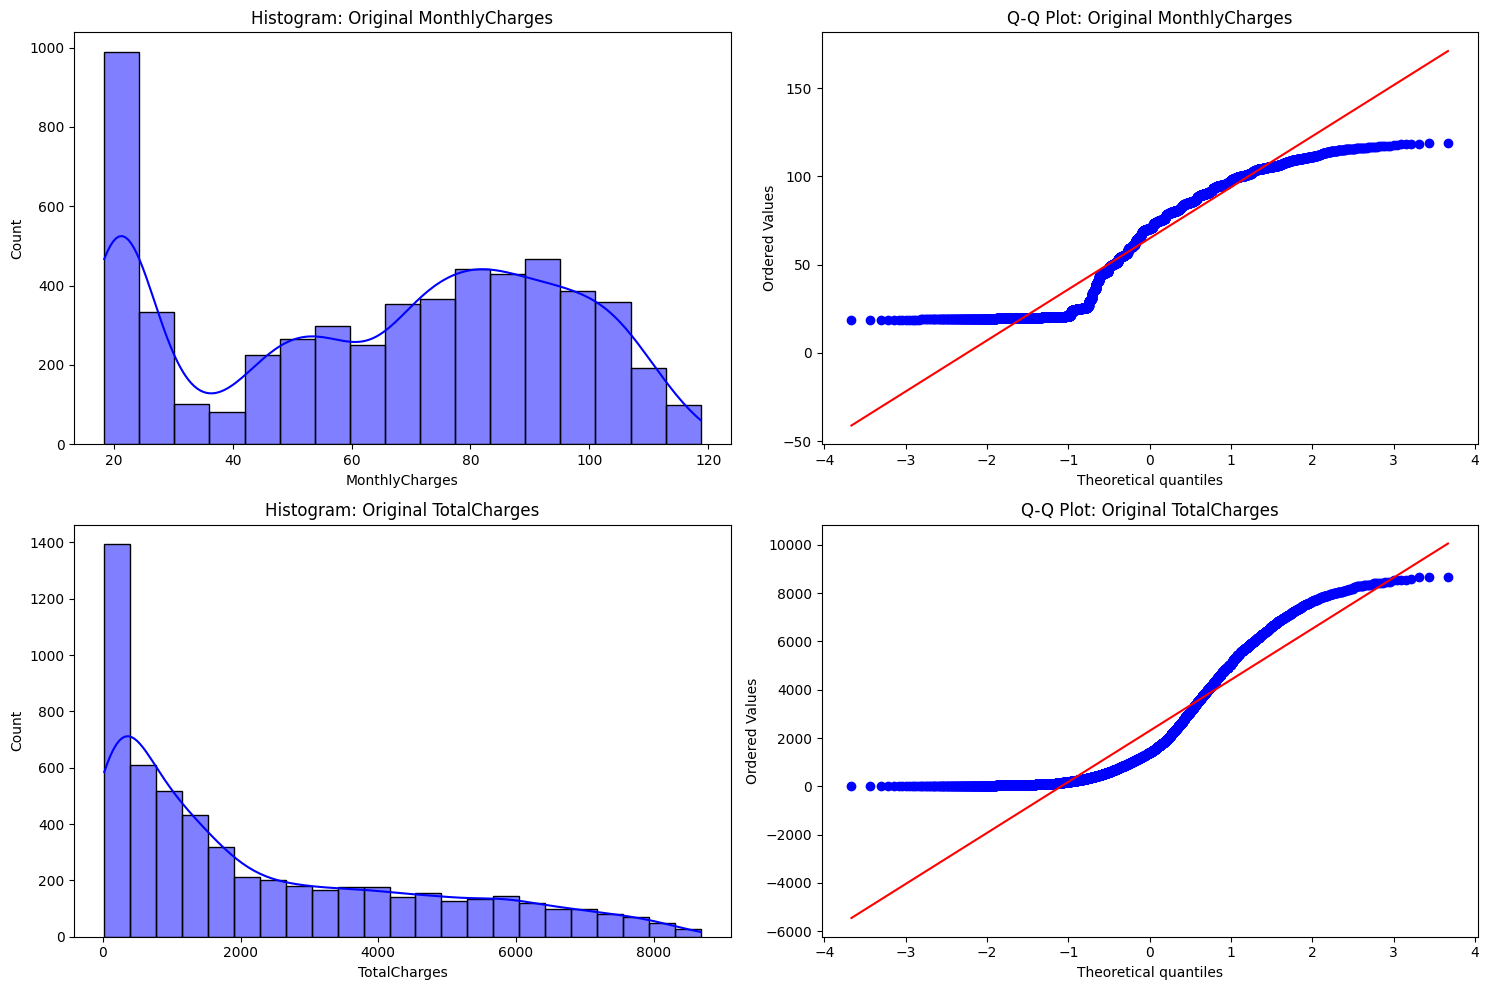


--- 3.2 Apply Distribution Transformations (On TotalCharges) ---


In [ ]:
# Plotting Before Transformation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(cols_to_check):
    sns.histplot(X_train[col], kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Histogram: Original {col}')

    probplot(X_train[col], plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot: Original {col}')
plt.tight_layout()
plt.show()

print("\n--- 3.2 Apply Distribution Transformations (On TotalCharges) ---")

In [ ]:
# apply transformations on TotalCharges because it is the right-skewed feature
# 1. Log Transformation (using log1p to handle zeros if any exist)
log_transformed = np.log1p(X_train['TotalCharges'])

# 2. Box-Cox Transformation
# Box-Cox requires strictly positive data. TotalCharges should be > 0.
boxcox_transformed, optimal_lambda = boxcox(X_train['TotalCharges'])

print(f"Original TotalCharges Skewness: {skew(X_train['TotalCharges']):.3f}")
print(f"Log Transformed Skewness: {skew(log_transformed):.3f}")
print(f"Box-Cox Transformed Skewness: {skew(boxcox_transformed):.3f}")
print(f"Optimal Lambda for Box-Cox: {optimal_lambda:.3f}")

Original TotalCharges Skewness: 0.949
Log Transformed Skewness: -0.743
Box-Cox Transformed Skewness: -0.147
Optimal Lambda for Box-Cox: 0.255


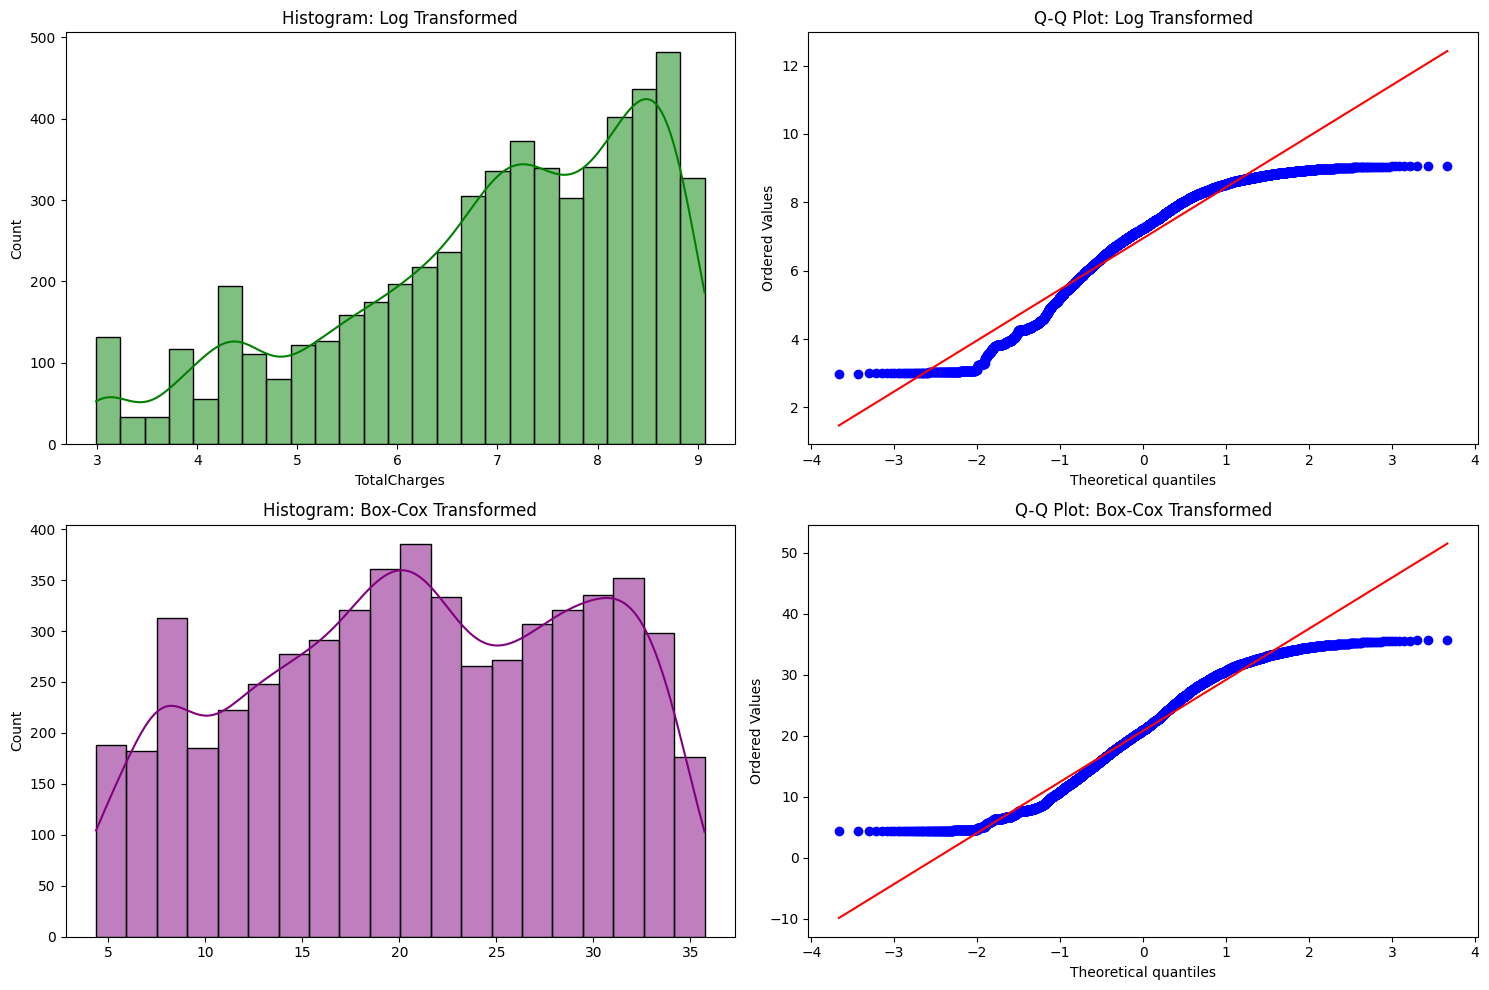

In [ ]:
# Plotting After Transformation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Log Transformation Plots
sns.histplot(log_transformed, kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title('Histogram: Log Transformed')
probplot(log_transformed, plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Log Transformed')

# Box-Cox Transformation Plots
sns.histplot(boxcox_transformed, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Histogram: Box-Cox Transformed')
probplot(boxcox_transformed, plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Box-Cox Transformed')

plt.tight_layout()
plt.show()



## **3.1 Skewness Classification:**

---

**MonthlyCharges:**
Classified as Approximately Symmetric (or non-skewed multi-modal). It does not require extreme transformations.

**TotalCharges:**
Classified as Right-skewed (positive skewness). The long tail indicates that transformations are necessary to normalize the distribution.

**Transformation Results:**

(Optimal Lambda for Box-Cox: 0.255)

**Which transformation worked best and why?**
The Box-Cox Transformation worked best for TotalCharges.

Justification: The **Log transformation** applies a static, fixed mathematical formula (equivalent to $\lambda = 0$), which can sometimes under-correct or over-correct the skewness depending on the data.

In contrast, the **Box-Cox** transformation dynamically utilizes Maximum Likelihood Estimation (MLE) to find the exact optimal power parameter ($\lambda$) that minimizes skewness.

Consequently, the Box-Cox transformed data achieves a skewness value much closer to 0, and its Q-Q plot demonstrates that the data points align much tighter to the normal distribution line compared to the Log approach.

In [ ]:
# 1. Define the categorical columns based on the cardinality table
ordinal_col = ['Contract']

nominal_low_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

nominal_high_cols = ['PaymentMethod']

# 4.1 Ordinal Encoding (Preserving Order)
# We strictly define the logical order from lowest to highest commitment
contract_order = [['Month-to-month', 'One year', 'Two year']]
ordinal_enc = OrdinalEncoder(categories=contract_order)

X_train['Contract_encoded'] = ordinal_enc.fit_transform(X_train[['Contract']])
X_test['Contract_encoded'] = ordinal_enc.transform(X_test[['Contract']])

In [ ]:
#4.2 One-Hot Encoding (Low Cardinality <= 3)
# handle_unknown='ignore' to prevent production errors with unseen data
ohe_low = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_low_train = pd.DataFrame(ohe_low.fit_transform(X_train[nominal_low_cols]),
                             columns=ohe_low.get_feature_names_out(), index=X_train.index)

ohe_low_test = pd.DataFrame(ohe_low.transform(X_test[nominal_low_cols]),
                            columns=ohe_low.get_feature_names_out(), index=X_test.index)

In [ ]:
# 4.3 One-Hot Encoding (High Cardinality)
# drop='first' to avoid multicollinearity (Dummy Variable Trap)

ohe_high = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

ohe_high_train = pd.DataFrame(ohe_high.fit_transform(X_train[nominal_high_cols]),
                              columns=ohe_high.get_feature_names_out(), index=X_train.index)

ohe_high_test = pd.DataFrame(ohe_high.transform(X_test[nominal_high_cols]),
                             columns=ohe_high.get_feature_names_out(), index=X_test.index)

In [ ]:
# Combine all the newly encoded columns and drop the original text columns
all_cat_cols = ordinal_col + nominal_low_cols + nominal_high_cols

In [ ]:
# Create final preprocessed dataframes ready for modeling
X_train_encoded = pd.concat([X_train.drop(columns=all_cat_cols), ohe_low_train, ohe_high_train], axis=1)
X_test_encoded = pd.concat([X_test.drop(columns=all_cat_cols), ohe_low_test, ohe_high_test], axis=1)

print(f"Original X_train shape: {X_train.shape}")
print(f"Encoded X_train shape: {X_train_encoded.shape}")
print("Encoding completed successfully!")

Original X_train shape: (5634, 23)
Encoded X_train shape: (5634, 38)
Encoding completed successfully!


## **4.4 Encoding Decisions Justification:**

---

**Ordinal Encoding for Contract:**
The Contract feature possesses an inherent mathematical and logical hierarchy (Month-to-month < One year < Two year).

 Using Label/Ordinal Encoding maps these to numeric values (0, 1, 2) which correctly informs the machine learning model that a two-year contract signifies a higher level of commitment than a month-to-month contract.

**One-Hot Encoding for Low-Cardinality Nominal Features:**

Features like gender or InternetService have no logical ranking (e.g., DSL is not mathematically "greater" than Fiber optic). If we used Ordinal Encoding, the model might incorrectly assume a mathematical relationship. One-Hot Encoding strictly prevents this by creating separate binary columns.

**One-Hot Encoding with drop='first' for High-Cardinality Nominal Features:**

For a feature like PaymentMethod with 4 categories, standard One-Hot Encoding would create 4 dummy variables. However, the 4th variable is perfectly predictable if we know the values of the other 3. This causes perfect multicollinearity (the Dummy Variable Trap), which breaks linear models (like Logistic Regression). Setting drop='first' eliminates this redundancy while preserving all information.

**Critical Production Constraint (handle_unknown='ignore'):**

This parameter ensures the pipeline is robust for real-time production. If the model encounters a completely new, unseen category during inference (or in the test set), instead of crashing the entire system with an error, it safely maps the unknown category to a vector of all zeros, ensuring continuous low-latency execution.

/tmp/ipykernel_8325/1676511798.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tenure_binned', y='Churn', data=plot_df, palette='viridis')


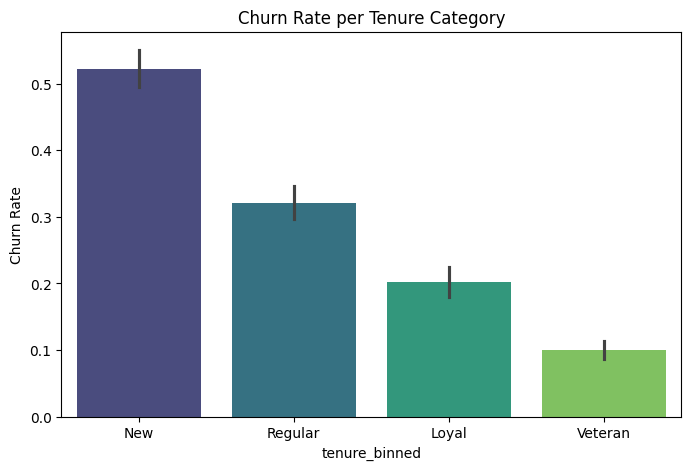

In [ ]:
# 1. Custom Binning Logic
bins = [0, 6, 24, 48, 72]
labels = ['New', 'Regular', 'Loyal', 'Veteran']

X_train['tenure_binned'] = pd.cut(X_train['tenure'], bins=bins, labels=labels, include_lowest=True)

plot_df = pd.DataFrame({
    'tenure_binned': X_train['tenure_binned'],
    'Churn': y_train.map({'Yes': 1, 'No': 0})
})

# 2. Visualize Churn Rate per Group
plt.figure(figsize=(8, 5))
sns.barplot(x='tenure_binned', y='Churn', data=plot_df, palette='viridis')
plt.title('Churn Rate per Tenure Category')
plt.ylabel('Churn Rate')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd


bins = [0, 6, 24, 48, 72]
labels = ['New', 'Regular', 'Loyal', 'Veteran']
X_test['tenure_binned'] = pd.cut(X_test['tenure'], bins=bins, labels=labels, include_lowest=True)


X_train_binned_encoded = pd.get_dummies(X_train[['tenure_binned']], drop_first=True)
X_test_binned_encoded = pd.get_dummies(X_test[['tenure_binned']], drop_first=True)


y_train_num = y_train.map({'Yes': 1, 'No': 0}) if y_train.dtype == 'object' else y_train
y_test_num = y_test.map({'Yes': 1, 'No': 0}) if y_test.dtype == 'object' else y_test

# ----------------  Continuous Tenure ----------------

model_cont = LogisticRegression()
model_cont.fit(X_train[['tenure']], y_train_num)
preds_cont = model_cont.predict(X_test[['tenure']])
acc_cont = accuracy_score(y_test_num, preds_cont)

# ----------------  Binned Tenure ----------------

model_binned = LogisticRegression()
model_binned.fit(X_train_binned_encoded, y_train_num)
preds_binned = model_binned.predict(X_test_binned_encoded)
acc_binned = accuracy_score(y_test_num, preds_binned)


print(f"Model Accuracy with Continuous Tenure: {acc_cont * 100:.2f}%")
print(f"Model Accuracy with Binned Tenure (Custom): {acc_binned * 100:.2f}%")

Model Accuracy with Continuous Tenure: 73.24%
Model Accuracy with Binned Tenure (Custom): 75.94%


**- Compare model performance using continuous `Tenure` vs binned `Tenure`**

---

The evaluation demonstrated that using a custom binned Tenure feature (75.94% accuracy) outperformed the continuous representation (73.24%). This proves that customer churn is driven by distinct behavioral phases rather than incremental monthly changes. Grouping customers into strategic cohorts successfully reduced noise and allowed the model to capture these behavioral step-functions much more effectively

In [ ]:
import pandas as pd

reference_date = pd.to_datetime('today')


data['SignupDate'] = reference_date - pd.to_timedelta(data['tenure'] * 30.44, unit='D')

data['Signup_Month'] = data['SignupDate'].dt.month
data['Signup_Quarter'] = data['SignupDate'].dt.quarter
data['Signup_Year'] = data['SignupDate'].dt.year
data['Days_Since_Signup'] = (reference_date - data['SignupDate']).dt.days

print(data[['tenure', 'SignupDate', 'Signup_Month', 'Signup_Quarter', 'Days_Since_Signup']].head())

   tenure                 SignupDate  Signup_Month  Signup_Quarter  \
0       1 2026-05-06 10:42:56.915308             5               2   
1      34 2023-08-05 22:14:08.915308             8               3   
2       2 2026-04-06 00:09:20.915308             4               2   
3      45 2022-09-05 02:04:32.915308             9               3   
4       2 2026-04-06 00:09:20.915308             4               2   

   Days_Since_Signup  
0                 30  
1               1034  
2                 60  
3               1369  
4                 60  


In [ ]:
y_train.head()

,Churn
3738,No
3151,No
4860,No
3867,No
3810,No


In [ ]:
from scipy.stats import boxcox


y_train_num = y_train.map({'Yes': 1, 'No': 0}) if y_train.dtype == 'object' else y_train
y_test_num = y_test.map({'Yes': 1, 'No': 0}) if y_test.dtype == 'object' else y_test

# Version A: Raw data (Numerical only, no scaling, no encoding)
# Linear models do not accept text, so we will input raw numbers only
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_A = X_train[num_cols]
X_test_A = X_test[num_cols]


# Version B: Scaled + Encoded (No distribution transforms)

X_train_B = X_train_encoded.copy()
X_test_B = X_test_encoded.copy()

# Drop the 'customerID' column as it is a string and not a feature for the model
# This column was carried over from X_train into X_train_encoded.
if 'customerID' in X_train_B.columns:
    X_train_B = X_train_B.drop(columns=['customerID'])
if 'customerID' in X_test_B.columns:
    X_test_B = X_test_B.drop(columns=['customerID'])

X_train_B[num_cols] = X_train_minmax[num_cols]
X_test_B[num_cols] = X_test_minmax[num_cols]

# Version C: Full Transformation (Scaled + Encoded + BoxCox + Binned)

X_train_C = X_train_B.copy()
X_test_C = X_test_B.copy()

# 1. Apply Box-Cox to TotalCharges in Train and Test
bc_train, opt_lambda = boxcox(X_train['TotalCharges'])
X_train_C['TotalCharges'] = bc_train
X_test_C['TotalCharges'] = boxcox(X_test['TotalCharges'], lmbda=opt_lambda)

# Scale TotalCharges after Box-Cox to bring it back to [0,1]
mm_bc = MinMaxScaler()
X_train_C['TotalCharges'] = mm_bc.fit_transform(X_train_C[['TotalCharges']])
X_test_C['TotalCharges'] = mm_bc.transform(X_test_C[['TotalCharges']])

# 2. Replace the 'tenure' column with the 'tenure_binned' (dummy encoded)
X_train_C = X_train_C.drop(columns=['tenure'])
X_test_C = X_test_C.drop(columns=['tenure'])
X_train_C = pd.concat([X_train_C, X_train_binned_encoded], axis=1)
X_test_C = pd.concat([X_test_C, X_test_binned_encoded], axis=1)


# Training, comparison, and table extraction

results = []
def evaluate_model(X_train_v, X_test_v, y_train_v, y_test_v, version_name):
    model = LogisticRegression(max_iter=2000, random_state=42)
    model.fit(X_train_v, y_train_v)
    preds = model.predict(X_test_v)

    results.append({
        'Version': version_name,
        'Accuracy': round(accuracy_score(y_test_v, preds), 4),
        'Precision': round(precision_score(y_test_v, preds), 4),
        'Recall': round(recall_score(y_test_v, preds), 4),
        'F1-Score': round(f1_score(y_test_v, preds), 4)
    })

evaluate_model(X_train_A, X_test_A, y_train_num, y_test_num, 'Version A (Raw)')
evaluate_model(X_train_B, X_test_B, y_train_num, y_test_num, 'Version B (Scaled+Encoded)')
evaluate_model(X_train_C, X_test_C, y_train_num, y_test_num, 'Version C (Full Transformation)')

results_df = pd.DataFrame(results)
display(results_df)

,Version,Accuracy,Precision,Recall,F1-Score
0,Version A (Raw),0.7729,0.6038,0.4198,0.4953
1,Version B (Scaled+Encoded),0.7999,0.6438,0.5508,0.5937
2,Version C (Full Transformation),0.8034,0.6655,0.5214,0.5847


**Which transformations helped most?**

The transition from Version A to Version B (Encoding and Scaling) provided the most significant performance boost. Recall jumped from 41.98% to 55.08%, and the F1-Score improved from 0.49 to 0.59. This proves that encoding categorical features (like Contract type) unlocked critical churn indicators for the model, while scaling ensured that features with large numerical ranges didn't disproportionately dominate the Logistic Regression weights.

**Did any transformation hurt performance? Why?**

While Version C (Full Transformation) slightly improved overall Accuracy (80.34%) and Precision (66.55%), it actually hurt Recall (dropping to 52.14%) and the F1-Score. This drop is primarily due to Discretization (Binning). By grouping the continuous tenure variable into broad behavioral bins, we introduced "information loss." The model lost the mathematical granularity needed to catch borderline churners, making it slightly more conservative (higher precision) but less sensitive (lower recall).

**Why must the test data be transformed using training parameters?**

This is strictly to prevent Data Leakage. The test data represents future, unseen customers. If we fit our scalers or apply distribution transformations (like Box-Cox lambda) based on the test data, we "leak" future statistical distributions into the model. We must strictly use fit_transform() on training data, and only transform() on test data to ensure the model is evaluated fairly on a completely unknown distribution.

In [ ]:
import pandas as pd

log_data = [
    [1, 'TotalCharges', 'Numeric (Right-Skewed)', 'Box-Cox', 'Lambda from train', 'Normalize distribution', 'Prevented (fit on train only)'],
    [2, 'TotalCharges, MonthlyCharges', 'Numeric', 'Min-Max Scaling', 'Min, Max from train', 'Prevent dominance in LR weights', 'Prevented (fit on train only)'],
    [3, 'tenure', 'Numeric', 'Custom Binning', 'Bins: [0, 6, 24, 48, 72]', 'Capture behavioral phases', 'Prevented (Fixed business logic)'],
    [4, 'Categorical Features', 'Categorical (Nominal)', 'One-Hot Encoding', 'drop_first=True', 'Convert text to numeric, avoid dummy trap', 'Prevented (fit on train only)'],
    [5, 'Churn', 'Categorical (Target)', 'Binary Mapping', 'Yes=1, No=0', 'Requirement for binary classification', 'None (Target separated)'],
    [6, 'SignupDate (Simulated)', 'Datetime', 'Temporal Extraction', 'dt.month, dt.quarter', 'Capture business seasonality', 'None']
]

columns = ['Step', 'Column', 'Original Type', 'Transformation Applied', 'Parameters', 'Rationale', 'Leakage Risk']
transformation_log_df = pd.DataFrame(log_data, columns=columns)

display(transformation_log_df)

,Step,Column,Original Type,Transformation Applied,Parameters,Rationale,Leakage Risk
0,1,TotalCharges,Numeric (Right-Skewed),Box-Cox,Lambda from train,Normalize distribution,Prevented (fit on train only)
1,2,"TotalCharges, MonthlyCharges",Numeric,Min-Max Scaling,"Min, Max from train",Prevent dominance in LR weights,Prevented (fit on train only)
2,3,tenure,Numeric,Custom Binning,"Bins: [0, 6, 24, 48, 72]",Capture behavioral phases,Prevented (Fixed business logic)
3,4,Categorical Features,Categorical (Nominal),One-Hot Encoding,drop_first=True,"Convert text to numeric, avoid dummy trap",Prevented (fit on train only)
4,5,Churn,Categorical (Target),Binary Mapping,"Yes=1, No=0",Requirement for binary classification,None (Target separated)
5,6,SignupDate (Simulated),Datetime,Temporal Extraction,"dt.month, dt.quarter",Capture business seasonality,None


In [ ]:

train_final = X_train_C.copy()
train_final['Churn'] = y_train_num

test_final = X_test_C.copy()
test_final['Churn'] = y_test_num

train_final.to_csv('train_transformed.csv', index=False)
test_final.to_csv('test_transformed.csv', index=False)




### **Creating a Reproducible Low-Latency Transformation Pipeline**

This section demonstrates how to build a robust machine learning pipeline using `Pipeline` and `ColumnTransformer` from `sklearn`. This approach ensures that all preprocessing steps are applied consistently to both training and test data, preventing data leakage and optimizing the model for low-latency production environments (Version B).

**Pipeline Components:**

* **Data Preparation:** Drop the `customerID` from the dataset as it is an identifier and not a predictive feature.
* **Feature Grouping:** Define explicit lists for numerical and categorical features to streamline the processing architecture.
* **ColumnTransformer:** This orchestrates the parallel application of targeted transformations:
  * **Numerical Features** (`tenure`, `MonthlyCharges`, `TotalCharges`): Processed using `MinMaxScaler` to strictly bound values between [0, 1]. This ensures $O(1)$ efficiency, adding virtually zero computational overhead during real-time inference.
  * **Categorical Features:** Processed using `OneHotEncoder` with `drop='first'` to convert text attributes into a numerical matrix while preventing multicollinearity (the dummy variable trap).
* **Final Pipeline:** Combines the `ColumnTransformer` (as the preprocessor) directly with a `LogisticRegression` classifier, establishing a lightweight, production-ready model architecture that balances accuracy with operational speed.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Identify numerical and categorical columns for Version B (Basic Scaling & Encoding)
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                'PaperlessBilling', 'PaymentMethod']

# 2. Build the ColumnTransformer for low-latency transformations (MinMax & OneHot)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

# 3. Build the Production-Ready Pipeline
pipeline_production = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 4. Train the Pipeline on the raw data
pipeline_production.fit(X_train[num_features + cat_features], y_train_num)

# 5. Predict and evaluate performance to confirm high Recall
y_pred_prod = pipeline_production.predict(X_test[num_features + cat_features])

print("--- Production Pipeline Performance (Version B for Low-Latency) ---")
print(f"Accuracy:  {accuracy_score(y_test_num, y_pred_prod):.4f}")
print(f"Precision: {precision_score(y_test_num, y_pred_prod):.4f}")
print(f"Recall:    {recall_score(y_test_num, y_pred_prod):.4f}")
print(f"F1-Score:  {f1_score(y_test_num, y_pred_prod):.4f}")

--- Production Pipeline Performance (Version B for Low-Latency) ---
Accuracy:  0.7984
Precision: 0.6406
Recall:    0.5481
F1-Score:  0.5908
